In [25]:
# Pytorch / 32w

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,OneHotEncoder,LabelEncoder,TargetEncoder
import keras
from keras.models import Sequential 
from keras.layers import Input, Dense

In [26]:
data=pd.read_csv("data\salary_dataset.csv")
print(data.shape)
data.dtypes

(30, 2)


YearsExperience    float64
Salary             float64
dtype: object

In [27]:
data.head(3)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0


In [28]:
X=data.iloc[:,:-1].values
Y=data.iloc[:,-1].values

In [29]:
# Split: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, train_size=0.7, random_state=42
)

In [30]:
scaler=StandardScaler()
X_train_scaler=scaler.fit_transform(X_train)
X_test_scaler=scaler.transform(X_test)

In [31]:
simple_model=Sequential([
    Input(shape=[1]),
    Dense(units=1, activation="linear")
])

In [32]:
simple_model.compile(optimizer="adam",loss="mean_squared_error",metrics=["mae"])

In [33]:
history=simple_model.fit(X_train_scaler,
          y_train,
          epochs=100,
          validation_data=(X_test_scaler,y_test),
          verbose=0
           )   #validation data for over fitting or early check

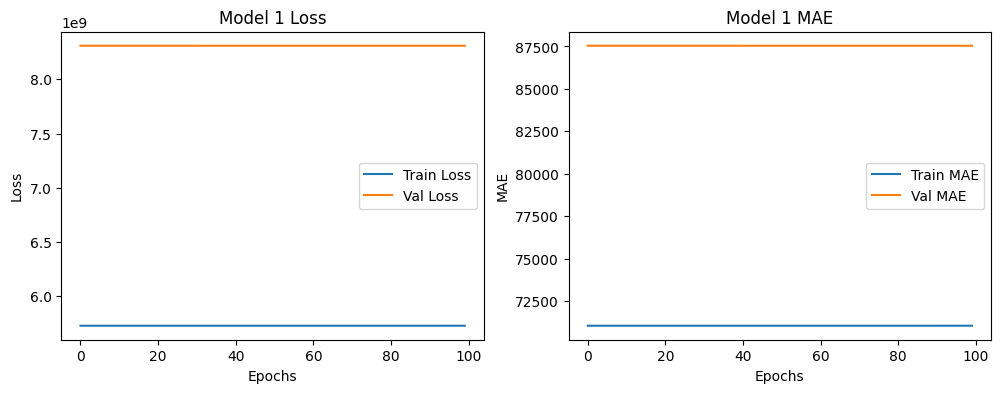

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Model 1 Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["mae"], label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("Model 1 MAE")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MAE")
axes[1].legend()